# Body vs Integrated Harmonics — MBB 2 Hz Campaign

**Goal:** Determine which harmonics have a *trustable* fringe correction and whether
the integrated value should be preferred over the body-only value.

## Table of Contents

<a id='sec1'></a>

1. [Configuration & Imports](#sec1)
2. [Data Loading](#sec2)
3. [SNR & Trustability Classification](#sec3)
4. [Body vs Integrated Spectrum](#sec4)
5. [Fringe Correction Physics](#sec5)
6. [Body-to-Integrated Difference Budget](#sec6)
7. [Cross-Energy Consistency Check](#sec7)
8. [Improvement Scenarios](#sec8)
9. [Practical Recommendations](#sec9)
10. [Summary & CSV Export](#sec10)

**Related notebooks:**
- `integrated_field.ipynb` — computes `integrated_harmonics.csv` and `integrated_field_summary.csv` (inputs to this analysis)
- `turn_averaging_sensitivity.ipynb` — validates the N_LAST=18 settling window
- `comparison.ipynb` — cross-energy B1/b2/b3 comparison
- `200GeV_analysis.ipynb`, `26GeV_analysis.ipynb` — per-energy pipeline producing the settled CSVs

In [1]:
"""Configuration & Imports."""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

%matplotlib widget
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

BAR_WIDTH = 0.35  # shared across all bar charts

In [2]:
"""Geometry constants & analysis parameters."""

# -- Repository root --
REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists():
        break
    REPO_ROOT = REPO_ROOT.parent

OUT_BASE = REPO_ROOT / "output" / "MBB" / "2026-02-25_2Hz"
OUT_INT  = OUT_BASE / "integrated_field"

# -- Geometry (must match integrated_field.ipynb) --
L_YOKE     = 6.200   # m, yoke length
L_COIL     = 0.470   # m, coil sensitive length per segment
L_SEG_MECH = 0.480   # m, mechanical length of one segment
L_GAP      = 0.100   # m, gap between segments
FRINGE_INSIDE_FRACTION = 1 / 3
L_BODY_EXCL = L_YOKE - 2 * FRINGE_INSIDE_FRACTION * L_COIL  # 5.887 m
N_BODY_EQUIV = L_BODY_EXCL / L_COIL  # 12.52

# -- Analysis configuration --
SEGMENTS  = ['CS', 'NCS']
ENERGIES  = ['200GeV', '26GeV']
LABELS    = ['injection', 'flat-high']
HARMONICS = list(range(2, 16))  # b2..b15

# -- SNR thresholds --
SNR_TRUSTABLE = 3.0   # |mean| / SE > 3  → harmonic is resolved
SNR_MARGINAL  = 1.5   # between 1.5 and 3 → marginal

# -- Noise floor (ADC-limited) --
NOISE_FLOOR_T = 2e-6  # ~2 µT RMS per turn in Tesla

print(f"REPO_ROOT:    {REPO_ROOT}")
print(f"L_BODY_EXCL:  {L_BODY_EXCL:.3f} m")
print(f"N_BODY_EQUIV: {N_BODY_EQUIV:.2f}")

REPO_ROOT:    C:\Users\albellel\python-projects\rotating-coil-analyzer
L_BODY_EXCL:  5.887 m
N_BODY_EQUIV: 12.52


<a id='sec2'></a>
## 2. Data Loading

We load the pre-computed integrated harmonics and per-turn settled data.

In [3]:
"""Load integrated harmonics & field summary."""

int_harm = pd.read_csv(OUT_INT / "integrated_harmonics.csv")
int_field = pd.read_csv(OUT_INT / "integrated_field_summary.csv")

print(f"Integrated harmonics: {len(int_harm)} rows")
print(f"Integrated field summary: {len(int_field)} rows")
display(int_field)

Integrated harmonics: 56 rows
Integrated field summary: 4 rows


,energy,label,I_A,B_body_T,B_fringe_T,seg_body,seg_fringe,TF_body,TF_fringe,B_int_Tm,L_mag_m,L_body_excl_m,N_body_equiv,TF_int_TmperkA
0,200GeV,injection,300.903540,0.116255,0.019622,CS,NCS,0.386352,0.065212,0.702797,6.045328,5.886667,12.524823,2.335622
1,200GeV,flat-high,4814.559700,1.781715,0.291179,CS,NCS,0.370068,0.060479,10.762071,6.040287,5.886667,12.524823,2.235318
2,26GeV,injection,300.917556,0.116255,0.019625,CS,NCS,0.386336,0.065219,0.702804,6.045349,5.886667,12.524823,2.335537
3,26GeV,flat-high,4814.572478,1.781749,0.291240,CS,NCS,0.370074,0.060491,10.762328,6.040316,5.886667,12.524823,2.235365


In [4]:
"""Load per-turn settled data for noise estimation."""

# Auto-detect body vs fringe from integrated_field_summary
row0 = int_field.iloc[0]
SEG_BODY   = row0['seg_body']    # CS
SEG_FRINGE = row0['seg_fringe']  # NCS
print(f"Body segment (DAQ label): {SEG_BODY}")
print(f"Fringe segment (DAQ label): {SEG_FRINGE}")

settled = {}
for energy in ENERGIES:
    edir = OUT_BASE / energy
    for seg in SEGMENTS:
        df = pd.read_csv(edir / f"MBB_{seg}_streaming_settled.csv")
        settled[(energy, seg)] = df
        n_inj = (df['label'] == 'injection').sum()
        n_fh  = (df['label'] == 'flat-high').sum()
        print(f"  {energy}/{seg}: {len(df)} turns (inj={n_inj}, fh={n_fh})")

Body segment (DAQ label): CS
Fringe segment (DAQ label): NCS
  200GeV/CS: 531 turns (inj=358, fh=173)
  200GeV/NCS: 532 turns (inj=359, fh=173)
  26GeV/CS: 537 turns (inj=361, fh=176)
  26GeV/NCS: 536 turns (inj=360, fh=176)


<a id='sec3'></a>
## 3. SNR & Trustability Classification

For each harmonic, we compute:

$$\text{SNR}_{\text{mean}} = \frac{|\bar{b}_n|}{\sigma / \sqrt{N}}$$

where $\sigma$ is the turn-to-turn standard deviation and $N$ the number of settled turns.
This tells us whether the **mean** is statistically resolved above noise.

| Verdict | Criterion |
|---------|----------|
| **TRUSTABLE** | SNR > 3.0 |
| **MARGINAL**  | 1.5 < SNR ≤ 3.0 |
| **NOISE**     | SNR ≤ 1.5 |

In [5]:
"""Compute SNR table for all harmonics / segments / labels."""


def compute_snr_table(settled_data, energies, segments, harmonics, labels):
    """Compute SNR = |mean| / SE for each harmonic.

    Returns DataFrame with columns:
        energy, label, segment, segment_type, n, mean, std, N, SE, SNR, verdict
    """
    rows = []
    for energy in energies:
        for seg in segments:
            df = settled_data[(energy, seg)]
            seg_type = 'body' if seg == SEG_BODY else 'fringe'
            for lbl in labels:
                sub = df[df['label'] == lbl]
                N = len(sub)
                if N < 2:
                    continue
                for n in harmonics:
                    col = f'b{n}_units'
                    vals = sub[col].values
                    mean = np.mean(vals)
                    std = np.std(vals, ddof=1)
                    SE = std / np.sqrt(N)
                    snr = abs(mean) / SE if SE > 0 else np.inf
                    if snr >= SNR_TRUSTABLE:
                        verdict = 'TRUSTABLE'
                    elif snr >= SNR_MARGINAL:
                        verdict = 'MARGINAL'
                    else:
                        verdict = 'NOISE'
                    rows.append(dict(
                        energy=energy, label=lbl, segment=seg,
                        segment_type=seg_type, n=n,
                        mean=mean, std=std, N=N, SE=SE,
                        SNR=snr, verdict=verdict,
                    ))
    return pd.DataFrame(rows)


snr_df = compute_snr_table(settled, ENERGIES, SEGMENTS, HARMONICS, LABELS)
print(f"SNR table: {len(snr_df)} rows")
snr_df.head(10)

SNR table: 112 rows


,energy,label,segment,segment_type,n,mean,std,N,SE,SNR,verdict
0,200GeV,injection,CS,body,2,0.021044,0.157076,358,0.008302,2.534916,MARGINAL
1,200GeV,injection,CS,body,3,-0.226131,0.090601,358,0.004788,47.224822,TRUSTABLE
2,200GeV,injection,CS,body,4,-0.035970,0.107389,358,0.005676,6.337529,TRUSTABLE
3,200GeV,injection,CS,body,5,-0.017630,0.141258,358,0.007466,2.361397,MARGINAL
4,200GeV,injection,CS,body,6,0.010787,0.166368,358,0.008793,1.226813,NOISE
5,200GeV,injection,CS,body,7,0.073348,0.228295,358,0.012066,6.079015,TRUSTABLE
6,200GeV,injection,CS,body,8,0.010726,0.288612,358,0.015254,0.703208,NOISE
7,200GeV,injection,CS,body,9,-0.127492,0.440244,358,0.023268,5.479362,TRUSTABLE
8,200GeV,injection,CS,body,10,-0.002248,0.613002,358,0.032398,0.069389,NOISE
9,200GeV,injection,CS,body,11,0.169701,0.849209,358,0.044882,3.781040,TRUSTABLE


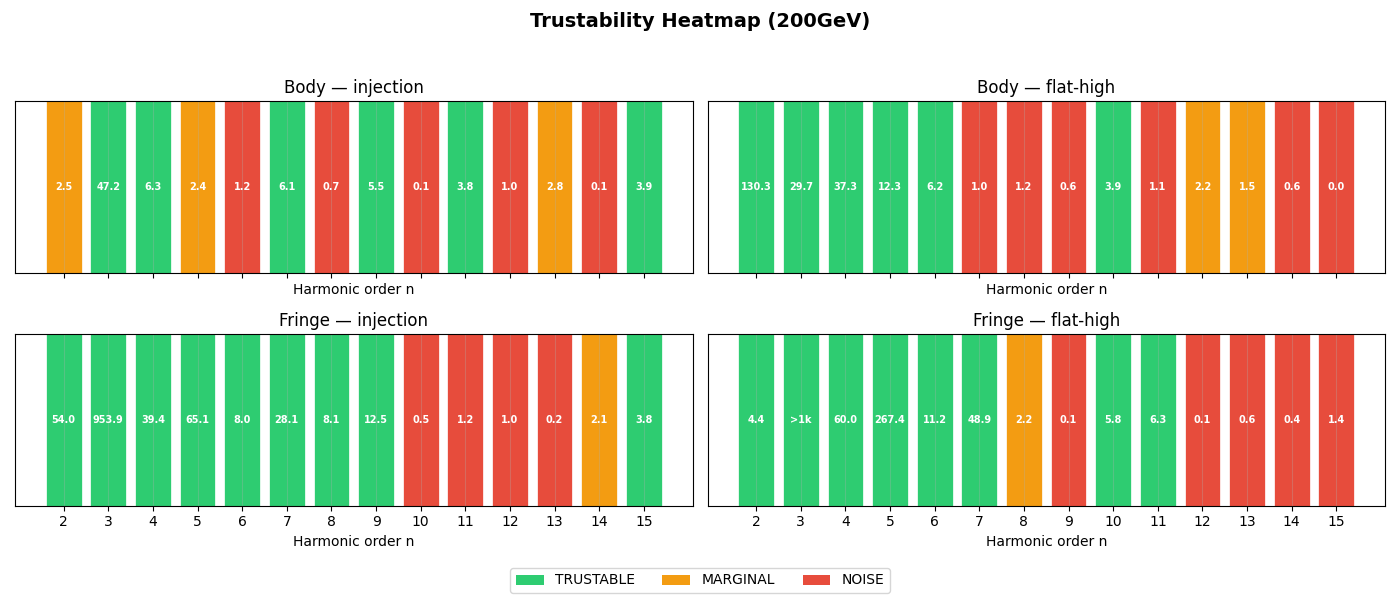

In [6]:
"""Trustability heatmap: 2x2 grid (body/fringe x injection/flat-top)."""

verdict_colors = {'TRUSTABLE': '#2ecc71', 'MARGINAL': '#f39c12', 'NOISE': '#e74c3c'}
verdict_order = ['TRUSTABLE', 'MARGINAL', 'NOISE']
cmap = mcolors.ListedColormap([verdict_colors[v] for v in verdict_order])
bounds = [0, 1, 2, 3]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

verdict_to_num = {'TRUSTABLE': 0.5, 'MARGINAL': 1.5, 'NOISE': 2.5}

ref_energy = '200GeV'
seg_types = ['body', 'fringe']

fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True, sharey=True)
fig.suptitle(f'Trustability Heatmap ({ref_energy})', fontsize=14, fontweight='bold')

for col_idx, lbl in enumerate(LABELS):
    for row_idx, stype in enumerate(seg_types):
        ax = axes[row_idx, col_idx]
        sub = snr_df[(snr_df['energy'] == ref_energy) &
                     (snr_df['label'] == lbl) &
                     (snr_df['segment_type'] == stype)].sort_values('n')
        colors = [verdict_colors[v] for v in sub['verdict']]
        ax.bar(sub['n'], 1, color=colors, edgecolor='white', linewidth=0.5)
        ax.set_title(f"{stype.capitalize()} — {lbl}")
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_xticks(HARMONICS)
        ax.set_xlabel('Harmonic order n')
        # Annotate SNR value
        for _, r in sub.iterrows():
            txt = f"{r['SNR']:.1f}" if r['SNR'] < 1000 else ">1k"
            ax.text(r['n'], 0.5, txt, ha='center', va='center',
                    fontsize=7, fontweight='bold', color='white')

# Legend
legend_elements = [Patch(facecolor=verdict_colors[v], label=v) for v in verdict_order]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10)
fig.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

In [7]:
"""Compact summary table: one row per harmonic."""

ref_energy = '200GeV'
summary_rows = []
for n in HARMONICS:
    row = {'n': n}
    for stype in ['body', 'fringe']:
        for lbl in LABELS:
            sub = snr_df[(snr_df['energy'] == ref_energy) &
                         (snr_df['label'] == lbl) &
                         (snr_df['segment_type'] == stype) &
                         (snr_df['n'] == n)]
            if len(sub) == 1:
                s = sub.iloc[0]
                key = f"{stype}_{lbl[:3]}"
                row[f'{key}_SNR'] = f"{s['SNR']:.1f}"
                row[f'{key}_verdict'] = s['verdict']
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(f"=== SNR Summary ({ref_energy}) ===")
display(summary_df)

=== SNR Summary (200GeV) ===


,n,body_inj_SNR,body_inj_verdict,body_fla_SNR,body_fla_verdict,fringe_inj_SNR,fringe_inj_verdict,fringe_fla_SNR,fringe_fla_verdict
0,2,2.5,MARGINAL,130.3,TRUSTABLE,54.0,TRUSTABLE,4.4,TRUSTABLE
1,3,47.2,TRUSTABLE,29.7,TRUSTABLE,953.9,TRUSTABLE,1052.8,TRUSTABLE
2,4,6.3,TRUSTABLE,37.3,TRUSTABLE,39.4,TRUSTABLE,60.0,TRUSTABLE
3,5,2.4,MARGINAL,12.3,TRUSTABLE,65.1,TRUSTABLE,267.4,TRUSTABLE
4,6,1.2,NOISE,6.2,TRUSTABLE,8.0,TRUSTABLE,11.2,TRUSTABLE
5,7,6.1,TRUSTABLE,1.0,NOISE,28.1,TRUSTABLE,48.9,TRUSTABLE
6,8,0.7,NOISE,1.2,NOISE,8.1,TRUSTABLE,2.2,MARGINAL
7,9,5.5,TRUSTABLE,0.6,NOISE,12.5,TRUSTABLE,0.1,NOISE
8,10,0.1,NOISE,3.9,TRUSTABLE,0.5,NOISE,5.8,TRUSTABLE
9,11,3.8,TRUSTABLE,1.1,NOISE,1.2,NOISE,6.3,TRUSTABLE


<a id='sec4'></a>
## 4. Body vs Integrated Spectrum

Side-by-side comparison of body-only and integrated harmonics at both energy levels.

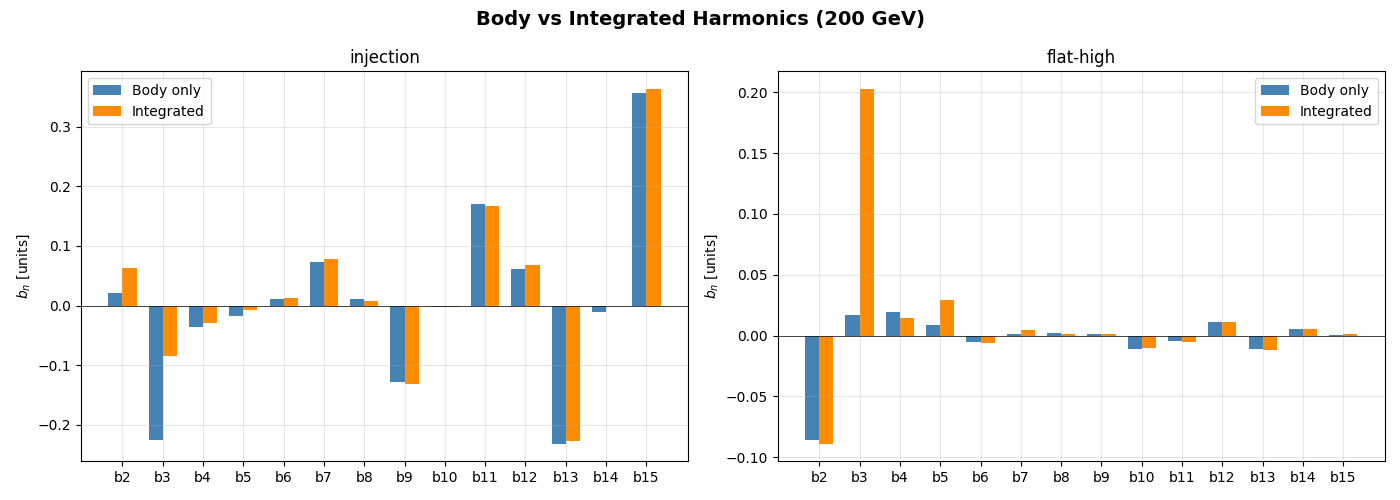

In [8]:
"""Side-by-side bar charts: body vs integrated, linear scale."""

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('Body vs Integrated Harmonics (200 GeV)', fontsize=14, fontweight='bold')

ref = '200GeV'

for ax_idx, lbl in enumerate(LABELS):
    ax = axes[ax_idx]
    sub = int_harm[(int_harm['energy'] == ref) & (int_harm['label'] == lbl)].sort_values('n')
    x = np.arange(len(sub))

    ax.bar(x - BAR_WIDTH / 2, sub['bn_body'], BAR_WIDTH, label='Body only', color='steelblue')
    ax.bar(x + BAR_WIDTH / 2, sub['bn_int'], BAR_WIDTH, label='Integrated', color='darkorange')

    ax.set_xticks(x)
    ax.set_xticklabels([f'b{n}' for n in sub['n']])
    ax.set_ylabel('$b_n$ [units]')
    ax.set_title(lbl)
    ax.legend()
    ax.axhline(0, color='k', linewidth=0.5)

fig.tight_layout()
plt.show()

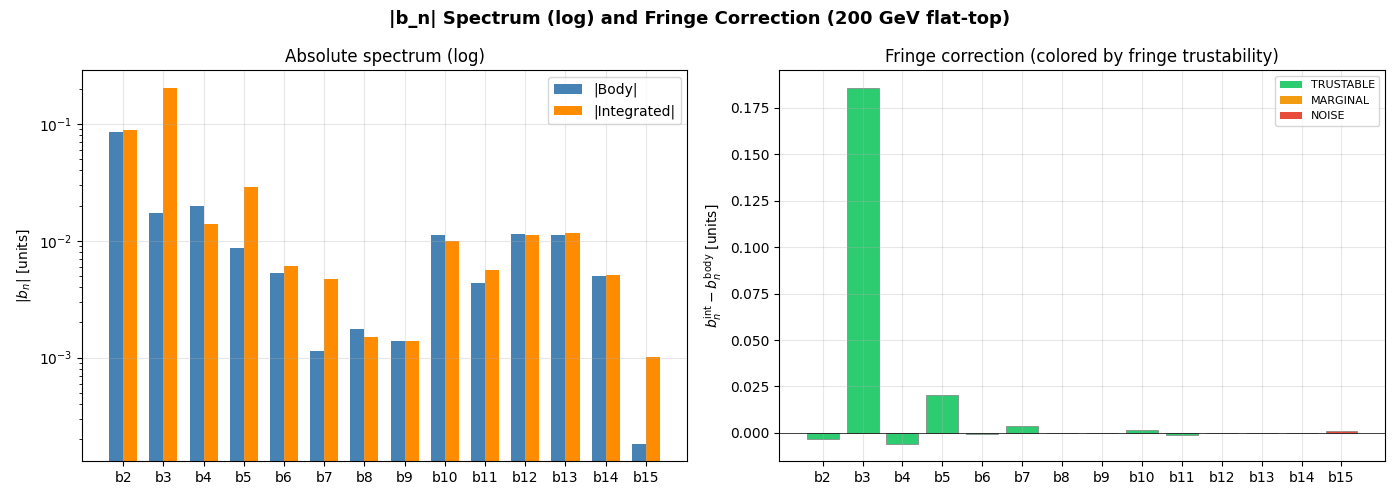

In [9]:
"""Log-scale absolute value + difference bar chart."""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('|b_n| Spectrum (log) and Fringe Correction (200 GeV flat-top)', fontsize=13, fontweight='bold')

ref, lbl = '200GeV', 'flat-high'
sub = int_harm[(int_harm['energy'] == ref) & (int_harm['label'] == lbl)].sort_values('n').copy()
x = np.arange(len(sub))

# Left: log-scale |b_n|
ax = axes[0]
ax.bar(x - BAR_WIDTH / 2, np.abs(sub['bn_body']), BAR_WIDTH, label='|Body|', color='steelblue')
ax.bar(x + BAR_WIDTH / 2, np.abs(sub['bn_int']), BAR_WIDTH, label='|Integrated|', color='darkorange')
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([f'b{n}' for n in sub['n']])
ax.set_ylabel('$|b_n|$ [units]')
ax.set_title('Absolute spectrum (log)')
ax.legend()

# Right: difference, colored by fringe trustability
ax = axes[1]
diff = sub['bn_int'].values - sub['bn_body'].values
fringe_verdicts = []
for n_val in sub['n'].values:
    v = snr_df[(snr_df['energy'] == ref) & (snr_df['label'] == lbl) &
              (snr_df['segment_type'] == 'fringe') & (snr_df['n'] == n_val)]
    fringe_verdicts.append(v.iloc[0]['verdict'] if len(v) else 'NOISE')
colors = [verdict_colors[v] for v in fringe_verdicts]

ax.bar(x, diff, color=colors, edgecolor='gray', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f'b{n}' for n in sub['n']])
ax.set_ylabel('$b_n^{\\mathrm{int}} - b_n^{\\mathrm{body}}$ [units]')
ax.set_title('Fringe correction (colored by fringe trustability)')
ax.axhline(0, color='k', linewidth=0.5)

legend_elements = [Patch(facecolor=verdict_colors[v], label=v) for v in verdict_order]
ax.legend(handles=legend_elements, fontsize=8)

fig.tight_layout()
plt.show()

<a id='sec5'></a>
## 5. Fringe Correction Physics

### Why fringe $b_n$ are large in *units* but small in *Tesla*

The harmonic unit is defined as $b_n = 10^4 \times C_n / B_1$. The fringe segment
has a much smaller $B_1$ (~0.065 T/kA vs ~0.386 T/kA for the body), so the same
absolute harmonic content $C_n$ in Tesla gets amplified by a factor of ~6 when
expressed in units.

**Rule:** Only trust the fringe correction when the fringe harmonic *itself*
is trustable (SNR > 3) — otherwise the large unit values are just amplified noise.

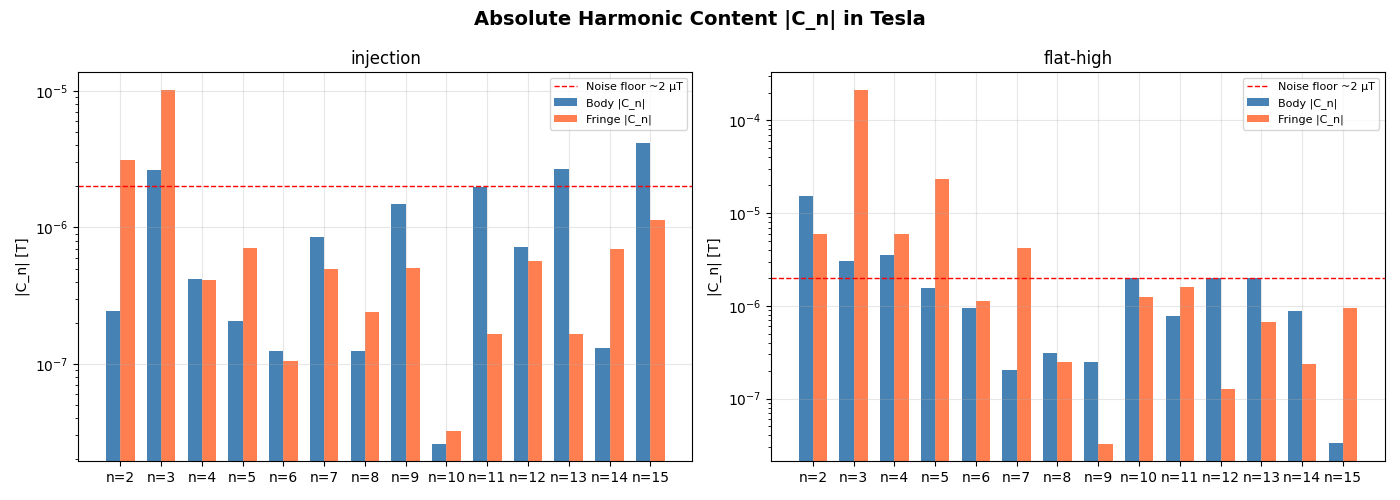

In [10]:
"""Absolute |C_n| in Tesla: body vs fringe (semilogy)."""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Absolute Harmonic Content |C_n| in Tesla', fontsize=14, fontweight='bold')

for ax_idx, lbl in enumerate(LABELS):
    ax = axes[ax_idx]
    sub = int_harm[(int_harm['energy'] == '200GeV') & (int_harm['label'] == lbl)].sort_values('n')
    x = np.arange(len(sub))

    ax.bar(x - BAR_WIDTH / 2, np.abs(sub['Cn_body_T']), BAR_WIDTH,
           label='Body |C_n|', color='steelblue')
    ax.bar(x + BAR_WIDTH / 2, np.abs(sub['Cn_fringe_T']), BAR_WIDTH,
           label='Fringe |C_n|', color='coral')
    ax.axhline(NOISE_FLOOR_T, color='red', linestyle='--', linewidth=1,
               label=f'Noise floor ~{NOISE_FLOOR_T*1e6:.0f} µT')

    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels([f'n={n}' for n in sub['n']])
    ax.set_ylabel('|C_n| [T]')
    ax.set_title(lbl)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

<a id='sec6'></a>
## 6. Body-to-Integrated Difference Budget

For each harmonic we assess whether the fringe correction is a **real** geometric
effect or just noise:

| Column | Meaning |
|--------|---------|
| `diff` | $b_n^{\text{int}} - b_n^{\text{body}}$ |
| `SE_body` | Standard error of body mean |
| `diff/SE` | Significance of the correction relative to body noise |
| `fringe_verdict` | Trustability of the fringe measurement |
| `status` | REAL / NOISE / UNCERTAIN |

In [11]:
"""Difference budget table for 200 GeV."""


def build_difference_budget(int_harm_df, snr_df, energy, label):
    """Build a per-harmonic budget of body→integrated correction."""
    sub = int_harm_df[(int_harm_df['energy'] == energy) &
                      (int_harm_df['label'] == label)].sort_values('n')
    rows = []
    for _, h in sub.iterrows():
        n = h['n']
        diff = h['bn_int'] - h['bn_body']

        # Body SE from SNR table
        body_row = snr_df[(snr_df['energy'] == energy) & (snr_df['label'] == label) &
                          (snr_df['segment_type'] == 'body') & (snr_df['n'] == n)]
        SE_body = body_row.iloc[0]['SE'] if len(body_row) else np.nan

        # Fringe verdict
        fringe_row = snr_df[(snr_df['energy'] == energy) & (snr_df['label'] == label) &
                            (snr_df['segment_type'] == 'fringe') & (snr_df['n'] == n)]
        fringe_verdict = fringe_row.iloc[0]['verdict'] if len(fringe_row) else 'NOISE'

        diff_over_SE = abs(diff) / SE_body if SE_body > 0 else np.inf

        # Correction status
        if fringe_verdict == 'TRUSTABLE' and diff_over_SE > 2:
            status = 'REAL'
        elif fringe_verdict == 'NOISE':
            status = 'NOISE'
        else:
            status = 'UNCERTAIN'

        rows.append(dict(
            n=n, bn_body=h['bn_body'], bn_int=h['bn_int'],
            diff=diff, SE_body=SE_body, diff_over_SE=diff_over_SE,
            fringe_verdict=fringe_verdict, status=status,
        ))
    return pd.DataFrame(rows)


budget_200_fh = build_difference_budget(int_harm, snr_df, '200GeV', 'flat-high')
budget_200_inj = build_difference_budget(int_harm, snr_df, '200GeV', 'injection')

print("=== Difference Budget: 200 GeV flat-top ===")
display(budget_200_fh)
print()
print("=== Difference Budget: 200 GeV injection ===")
display(budget_200_inj)

=== Difference Budget: 200 GeV flat-top ===


,n,bn_body,bn_int,diff,SE_body,diff_over_SE,fringe_verdict,status
0,2,-0.085886,-0.088927,-0.003041,0.000659,4.613203,TRUSTABLE,REAL
1,3,0.017139,0.202829,0.185690,0.000577,321.644235,TRUSTABLE,REAL
2,4,0.019712,0.013996,-0.005716,0.000529,10.811320,TRUSTABLE,REAL
3,5,0.008635,0.029049,0.020414,0.000701,29.105261,TRUSTABLE,REAL
4,6,-0.005266,-0.006123,-0.000857,0.000849,1.009023,TRUSTABLE,UNCERTAIN
5,7,0.001130,0.004754,0.003625,0.001156,3.135233,TRUSTABLE,REAL
6,8,0.001751,0.001488,-0.000263,0.001472,0.178626,MARGINAL,UNCERTAIN
7,9,0.001386,0.001379,-0.000007,0.002166,0.003110,NOISE,NOISE
8,10,-0.011263,-0.009899,0.001363,0.002891,0.471450,TRUSTABLE,UNCERTAIN
9,11,-0.004316,-0.005611,-0.001295,0.004006,0.323291,TRUSTABLE,UNCERTAIN



=== Difference Budget: 200 GeV injection ===


,n,bn_body,bn_int,diff,SE_body,diff_over_SE,fringe_verdict,status
0,2,0.021044,0.062500,0.041456,0.008302,4.993650,TRUSTABLE,REAL
1,3,-0.226131,-0.084491,0.141640,0.004788,29.579807,TRUSTABLE,REAL
2,4,-0.035970,-0.029483,0.006486,0.005676,1.142852,TRUSTABLE,UNCERTAIN
3,5,-0.017630,-0.007750,0.009879,0.007466,1.323312,TRUSTABLE,UNCERTAIN
4,6,0.010787,0.011908,0.001121,0.008793,0.127495,TRUSTABLE,UNCERTAIN
5,7,0.073348,0.078049,0.004701,0.012066,0.389591,TRUSTABLE,UNCERTAIN
6,8,0.010726,0.007210,-0.003517,0.015254,0.230563,TRUSTABLE,UNCERTAIN
7,9,-0.127492,-0.130935,-0.003443,0.023268,0.147974,TRUSTABLE,UNCERTAIN
8,10,-0.002248,-0.002619,-0.000371,0.032398,0.011439,NOISE,NOISE
9,11,0.169701,0.167471,-0.002230,0.044882,0.049687,NOISE,NOISE


<a id='sec7'></a>
## 7. Cross-Energy Consistency Check

If a fringe correction is **real** (geometry-driven), it should be similar at both
200 GeV and 26 GeV — the field shape scales with current but the geometric
contribution of the fringe should be consistent.

We compare the correction $\Delta b_n = b_n^{\text{int}} - b_n^{\text{body}}$
at both energies.

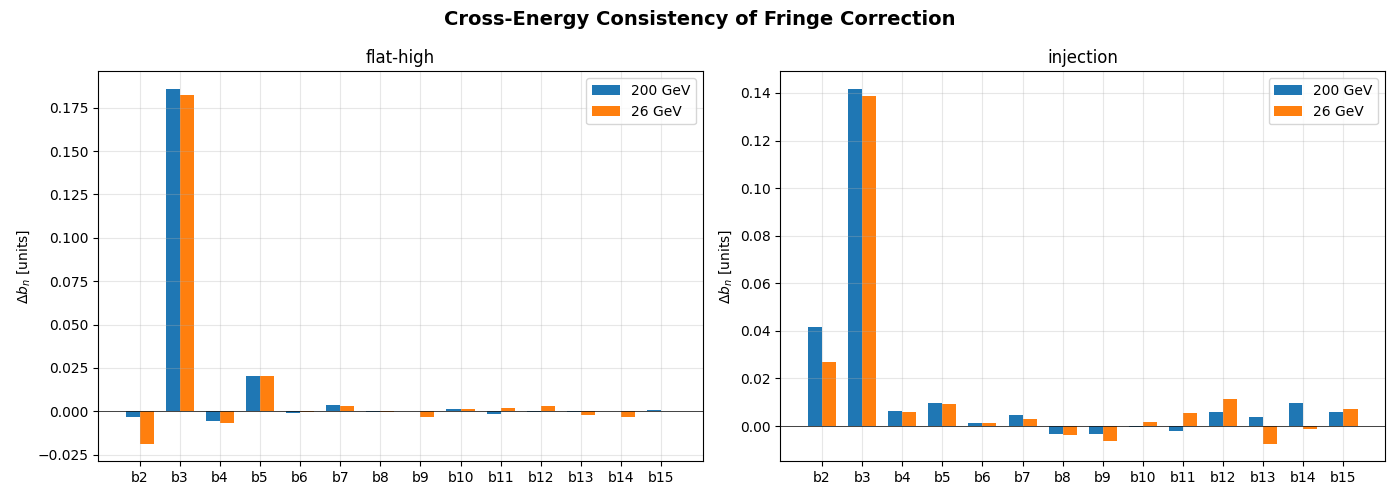

In [12]:
"""Cross-energy consistency: fringe correction at both energies."""

budget_26_fh = build_difference_budget(int_harm, snr_df, '26GeV', 'flat-high')
budget_26_inj = build_difference_budget(int_harm, snr_df, '26GeV', 'injection')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross-Energy Consistency of Fringe Correction', fontsize=14, fontweight='bold')

for ax_idx, (lbl, b200, b26) in enumerate([
    ('flat-high', budget_200_fh, budget_26_fh),
    ('injection', budget_200_inj, budget_26_inj),
]):
    ax = axes[ax_idx]
    x = np.arange(len(HARMONICS))
    ax.bar(x - BAR_WIDTH / 2, b200['diff'].values, BAR_WIDTH,
           label='200 GeV', color='tab:blue')
    ax.bar(x + BAR_WIDTH / 2, b26['diff'].values, BAR_WIDTH,
           label='26 GeV', color='tab:orange')
    ax.set_xticks(x)
    ax.set_xticklabels([f'b{n}' for n in HARMONICS])
    ax.set_ylabel('$\\Delta b_n$ [units]')
    ax.set_title(lbl)
    ax.legend()
    ax.axhline(0, color='k', linewidth=0.5)

fig.tight_layout()
plt.show()

In [13]:
"""Cross-energy consistency table."""

consistency_rows = []
for lbl, b200, b26 in [
    ('flat-high', budget_200_fh, budget_26_fh),
    ('injection', budget_200_inj, budget_26_inj),
]:
    for i, n in enumerate(HARMONICS):
        d200 = b200.iloc[i]['diff']
        d26 = b26.iloc[i]['diff']
        delta = abs(d200 - d26)
        avg_abs = (abs(d200) + abs(d26)) / 2
        consistent = 'YES' if (delta < 0.1 or (avg_abs > 0 and delta / avg_abs < 0.5)) else 'NO'
        consistency_rows.append(dict(
            label=lbl, n=n,
            diff_200=round(d200, 4), diff_26=round(d26, 4),
            delta=round(delta, 4), consistent=consistent,
        ))

consistency_df = pd.DataFrame(consistency_rows)
print("=== Cross-Energy Consistency ===")
display(consistency_df[consistency_df['label'] == 'flat-high'])

=== Cross-Energy Consistency ===


,label,n,diff_200,diff_26,delta,consistent
0,flat-high,2,-0.0030,-0.0185,0.0155,YES
1,flat-high,3,0.1857,0.1825,0.0032,YES
2,flat-high,4,-0.0057,-0.0069,0.0012,YES
3,flat-high,5,0.0204,0.0203,0.0001,YES
4,flat-high,6,-0.0009,-0.0005,0.0004,YES
5,flat-high,7,0.0036,0.0034,0.0002,YES
6,flat-high,8,-0.0003,-0.0002,0.0000,YES
7,flat-high,9,-0.0000,-0.0034,0.0034,YES
8,flat-high,10,0.0014,0.0016,0.0003,YES
9,flat-high,11,-0.0013,0.0018,0.0031,YES


<a id='sec8'></a>
## 8. Improvement Scenarios

We project how the SNR would improve under different measurement configurations:

| Scenario | Effect on noise |
|----------|----------------|
| **4 Hz** (2× rotation speed) | 2× turns in same time → $\sqrt{2}$ SNR gain |
| **2× supercycles** | 2× total turns → $\sqrt{2}$ SNR gain |
| **4 Hz + 2× SC** (combined) | 4× turns → 2× SNR gain |

The fundamental limit is the ADC noise floor (~2 µT per turn). At injection
(B1 ≈ 0.116 T), 1 unit = B1/10⁴ ≈ 11.6 µT. The noise floor in units is
~2 µT / 11.6 µT ≈ 0.17 units — most high-order harmonics are below this.

In [14]:
"""Projected SNR under improvement scenarios."""

scenarios = {
    'Current (2 Hz)':    1.0,
    '4 Hz':              np.sqrt(2),
    '2x supercycles':    np.sqrt(2),
    '4 Hz + 2x SC':      2.0,
}

ref_energy = '200GeV'
proj_rows = []

for n in HARMONICS:
    row = {'n': n}
    for lbl in LABELS:
        for stype in ['body', 'fringe']:
            sub = snr_df[(snr_df['energy'] == ref_energy) & (snr_df['label'] == lbl) &
                         (snr_df['segment_type'] == stype) & (snr_df['n'] == n)]
            if len(sub) == 0:
                continue
            base_snr = sub.iloc[0]['SNR']
            for sc_name, gain in scenarios.items():
                key = f"{stype}_{lbl[:3]}_{sc_name}"
                row[key] = base_snr * gain
    proj_rows.append(row)

proj_df = pd.DataFrame(proj_rows)

# Print concise view: body injection only (the bottleneck)
print("=== Projected Body SNR at Injection (200 GeV) ===")
cols_to_show = ['n'] + [f'body_inj_{sc}' for sc in scenarios]
display(proj_df[cols_to_show].round(1))

=== Projected Body SNR at Injection (200 GeV) ===


,n,body_inj_Current (2 Hz),body_inj_4 Hz,body_inj_2x supercycles,body_inj_4 Hz + 2x SC
0,2,2.5,3.6,3.6,5.1
1,3,47.2,66.8,66.8,94.4
2,4,6.3,9.0,9.0,12.7
3,5,2.4,3.3,3.3,4.7
4,6,1.2,1.7,1.7,2.5
5,7,6.1,8.6,8.6,12.2
6,8,0.7,1.0,1.0,1.4
7,9,5.5,7.7,7.7,11.0
8,10,0.1,0.1,0.1,0.1
9,11,3.8,5.3,5.3,7.6


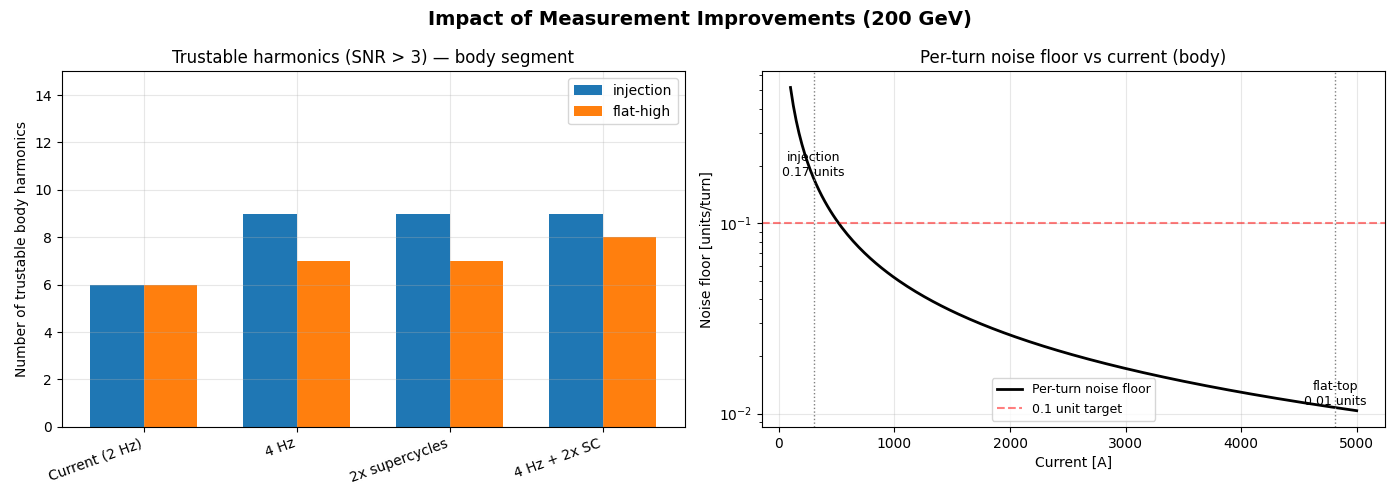

In [15]:
"""Plot: number of trustable body harmonics per scenario at injection."""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impact of Measurement Improvements (200 GeV)', fontsize=14, fontweight='bold')

# Left: bar chart of trustable harmonic count
ax = axes[0]
for lbl_idx, lbl in enumerate(LABELS):
    counts = []
    labels_sc = []
    for sc_name, gain in scenarios.items():
        key = f'body_{lbl[:3]}_{sc_name}'
        if key in proj_df.columns:
            n_trustable = (proj_df[key] >= SNR_TRUSTABLE).sum()
        else:
            n_trustable = 0
        counts.append(n_trustable)
        labels_sc.append(sc_name)

    x = np.arange(len(labels_sc))
    offset = (lbl_idx - 0.5) * BAR_WIDTH
    ax.bar(x + offset, counts, BAR_WIDTH, label=lbl)

ax.set_xticks(np.arange(len(labels_sc)))
ax.set_xticklabels(labels_sc, rotation=20, ha='right')
ax.set_ylabel('Number of trustable body harmonics')
ax.set_title('Trustable harmonics (SNR > 3) — body segment')
ax.legend()
ax.set_ylim(0, 15)

# Right: noise floor in units vs current
ax = axes[1]
I_range = np.linspace(100, 5000, 200)
# TF ~ 0.386 T/kA for body
TF_body = 0.386e-3  # T/A
B1_vs_I = TF_body * I_range
noise_units = NOISE_FLOOR_T / B1_vs_I * 1e4  # per turn

ax.semilogy(I_range, noise_units, 'k-', linewidth=2, label='Per-turn noise floor')

# Mark injection and flat-top
I_inj, I_ft = 301, 4815
for I_val, name in [(I_inj, 'injection'), (I_ft, 'flat-top')]:
    nf = NOISE_FLOOR_T / (TF_body * I_val) * 1e4
    ax.axvline(I_val, color='gray', linestyle=':', linewidth=1)
    ax.annotate(f'{name}\n{nf:.2f} units', xy=(I_val, nf),
                fontsize=9, ha='center', va='bottom')

ax.set_xlabel('Current [A]')
ax.set_ylabel('Noise floor [units/turn]')
ax.set_title('Per-turn noise floor vs current (body)')
ax.axhline(0.1, color='red', linestyle='--', alpha=0.5, label='0.1 unit target')
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

In [16]:
"""Projected SNR table for body flat-top."""

print("=== Projected Body SNR at Flat-Top (200 GeV) ===")
cols_fh = ['n'] + [f'body_fla_{sc}' for sc in scenarios]
# Column name uses first 3 chars of label: 'flat-high' -> 'fla'
display(proj_df[cols_fh].round(1))

=== Projected Body SNR at Flat-Top (200 GeV) ===


,n,body_fla_Current (2 Hz),body_fla_4 Hz,body_fla_2x supercycles,body_fla_4 Hz + 2x SC
0,2,130.3,184.3,184.3,260.6
1,3,29.7,42.0,42.0,59.4
2,4,37.3,52.7,52.7,74.6
3,5,12.3,17.4,17.4,24.6
4,6,6.2,8.8,8.8,12.4
5,7,1.0,1.4,1.4,2.0
6,8,1.2,1.7,1.7,2.4
7,9,0.6,0.9,0.9,1.3
8,10,3.9,5.5,5.5,7.8
9,11,1.1,1.5,1.5,2.2


### Discussion: Fundamental Limits

- **At injection** (I = 301 A, B1 ~ 0.116 T): 1 unit = 11.6 uT. The ADC noise
  floor (~2 uT/turn) means the per-turn noise is ~0.17 units. With ~360 settled
  turns, SE ~ 0.17/sqrt(360) ~ 0.009 units. This resolves b3 (~0.23 units)
  and the allowed odd harmonics (b7, b9, b11, b15) whose means are ~0.07-0.36
  units. Even harmonics (b6, b8, b10, b12, b14) are consistent with zero at
  injection -- as expected by dipole symmetry.

- **At flat-top** (I = 4815 A, B1 ~ 1.78 T): 1 unit = 178 uT. Noise is
  ~0.011 units/turn, and with averaging, SE ~ 0.001 units. Harmonics b2-b6
  are well-resolved; b7 and above become marginal because their *absolute*
  harmonic content (in Tesla) is small, not because the noise is high.

- **4 Hz helps moderately** (sqrt(2) gain) but won't make even-order body
  harmonics trustable at injection -- they are genuinely near zero by symmetry.

- **Odd vs even pattern at injection**: The alternating trustable/noise pattern
  (b3 YES, b4 YES, b5 MARGINAL, b6 NO, b7 YES, b8 NO, ...) reflects dipole
  magnet symmetry: allowed harmonics are n=3,5,7,9,... (odd order). Even-order
  harmonics arise only from misalignment or persistent currents and are typically
  near zero at injection.

<a id='sec9'></a>
## 9. Practical Recommendations

For each harmonic, we recommend whether to use the **integrated** value,
the **body-only** value, or flag it as **not trustable**.

In [17]:
"""Final recommendation table."""


def build_recommendations(budget_df, snr_df, energy, label):
    """Generate per-harmonic recommendation.

    Logic:
    - If body is NOISE → NOT TRUSTABLE
    - If fringe is TRUSTABLE and correction is significant → INTEGRATED
    - Otherwise → BODY (or BODY* if body is MARGINAL)
    """
    rows = []
    for _, b in budget_df.iterrows():
        n = b['n']
        body_v = snr_df[(snr_df['energy'] == energy) & (snr_df['label'] == label) &
                        (snr_df['segment_type'] == 'body') & (snr_df['n'] == n)]
        body_verdict = body_v.iloc[0]['verdict'] if len(body_v) else 'NOISE'
        body_snr = body_v.iloc[0]['SNR'] if len(body_v) else 0

        if body_verdict == 'NOISE':
            rec = 'NOT TRUSTABLE'
            reason = 'Body SNR too low'
        elif b['status'] == 'REAL':
            rec = 'INTEGRATED'
            qualifier = ' (body marginal)' if body_verdict == 'MARGINAL' else ''
            reason = f"Fringe correction {b['diff']:+.3f} units (REAL){qualifier}"
        else:
            rec = 'BODY'
            qualifier = ' (marginal)' if body_verdict == 'MARGINAL' else ''
            reason = f"Fringe {b['fringe_verdict'].lower()}, correction {b['diff']:+.4f} units{qualifier}"

        rows.append(dict(
            n=n, bn_body=round(b['bn_body'], 4),
            bn_int=round(b['bn_int'], 4),
            diff=round(b['diff'], 4),
            body_SNR=round(body_snr, 1),
            body_verdict=body_verdict,
            fringe_verdict=b['fringe_verdict'],
            recommendation=rec,
            reason=reason,
        ))
    return pd.DataFrame(rows)


rec_200_fh = build_recommendations(budget_200_fh, snr_df, '200GeV', 'flat-high')
rec_200_inj = build_recommendations(budget_200_inj, snr_df, '200GeV', 'injection')

print("=== Recommendations: 200 GeV Flat-Top ===")
display(rec_200_fh)
print()
print("=== Recommendations: 200 GeV Injection ===")
display(rec_200_inj)

=== Recommendations: 200 GeV Flat-Top ===

,n,bn_body,bn_int,diff,body_SNR,body_verdict,fringe_verdict,recommendation,reason
0,2,-0.0859,-0.0889,-0.0030,130.3,TRUSTABLE,TRUSTABLE,INTEGRATED,Fringe correction -0.003 units (REAL)
1,3,0.0171,0.2028,0.1857,29.7,TRUSTABLE,TRUSTABLE,INTEGRATED,Fringe correction +0.186 units (REAL)
2,4,0.0197,0.0140,-0.0057,37.3,TRUSTABLE,TRUSTABLE,INTEGRATED,Fringe correction -0.006 units (REAL)
3,5,0.0086,0.0290,0.0204,12.3,TRUSTABLE,TRUSTABLE,INTEGRATED,Fringe correction +0.020 units (REAL)
4,6,-0.0053,-0.0061,-0.0009,6.2,TRUSTABLE,TRUSTABLE,BODY,"Fringe trustable, correction -0.0009 units"
5,7,0.0011,0.0048,0.0036,1.0,NOISE,TRUSTABLE,NOT TRUSTABLE,Body SNR too low
6,8,0.0018,0.0015,-0.0003,1.2,NOISE,MARGINAL,NOT TRUSTABLE,Body SNR too low
7,9,0.0014,0.0014,-0.0000,0.6,NOISE,NOISE,NOT TRUSTABLE,Body SNR too low
8,10,-0.0113,-0.0099,0.0014,3.9,TRUSTABLE,TRUSTABLE,BODY,"Fringe trustable, correction +0.0014 units"
9,11,-0.0043,-0.0056,-0.0013,1.1,NOISE,TRUSTABLE,NOT TRUSTABLE,Body SNR too low



=== Recommendations: 200 GeV Injection ===


,n,bn_body,bn_int,diff,body_SNR,body_verdict,fringe_verdict,recommendation,reason
0,2,0.0210,0.0625,0.0415,2.5,MARGINAL,TRUSTABLE,INTEGRATED,Fringe correction +0.041 units (REAL) (body ma...
1,3,-0.2261,-0.0845,0.1416,47.2,TRUSTABLE,TRUSTABLE,INTEGRATED,Fringe correction +0.142 units (REAL)
2,4,-0.0360,-0.0295,0.0065,6.3,TRUSTABLE,TRUSTABLE,BODY,"Fringe trustable, correction +0.0065 units"
3,5,-0.0176,-0.0078,0.0099,2.4,MARGINAL,TRUSTABLE,BODY,"Fringe trustable, correction +0.0099 units (ma..."
4,6,0.0108,0.0119,0.0011,1.2,NOISE,TRUSTABLE,NOT TRUSTABLE,Body SNR too low
5,7,0.0733,0.0780,0.0047,6.1,TRUSTABLE,TRUSTABLE,BODY,"Fringe trustable, correction +0.0047 units"
6,8,0.0107,0.0072,-0.0035,0.7,NOISE,TRUSTABLE,NOT TRUSTABLE,Body SNR too low
7,9,-0.1275,-0.1309,-0.0034,5.5,TRUSTABLE,TRUSTABLE,BODY,"Fringe trustable, correction -0.0034 units"
8,10,-0.0022,-0.0026,-0.0004,0.1,NOISE,NOISE,NOT TRUSTABLE,Body SNR too low
9,11,0.1697,0.1675,-0.0022,3.8,TRUSTABLE,NOISE,BODY,"Fringe noise, correction -0.0022 units"


### Narrative Summary

**For beam optics (flat-top):**
- b2-b6 are well-resolved in the body segment (SNR > 6).
- b3 has a large, real fringe correction (~+0.19 units, consistent at both energies).
  Use the **integrated** value for b3 at flat-top.
- b2, b4, b5 also have small but statistically significant fringe corrections
  (0.003-0.020 units); use integrated values.
- b7 and higher become marginal or noise in the body at flat-top;
  for these, neither body nor integrated is fully trustable.

**For injection quality:**
- Odd-order allowed harmonics (b3, b7, b9, b11, b15) are resolved in the body,
  reflecting dipole symmetry and persistent-current contributions.
- Even-order harmonics (b6, b8, b10, b12, b14) are consistent with zero at injection
  (as expected for a symmetric dipole).
- b2 body is MARGINAL (SNR=2.5) but the fringe correction (+0.041 units) is real
  and significant; the integrated value is more appropriate.
- b3 fringe correction at injection (+0.14 units) is also real; use integrated.
- The fringe segment at injection has high SNR for low-order harmonics (b2-b8
  all trustable, SNR > 8) due to the smaller $B_1$ amplification.
  However, this only matters for harmonics where the fringe correction is significant.

<a id='sec10'></a>
## 10. Summary & CSV Export

In [18]:
"""Export CSV files."""

OUT_INT.mkdir(parents=True, exist_ok=True)

# 1. SNR trustability table
snr_df.to_csv(OUT_INT / "snr_trustability.csv", index=False)
print(f"Saved: {OUT_INT / 'snr_trustability.csv'}")

# 2. Body vs integrated budget (all energies/labels)
budget_all = pd.concat([
    budget_200_fh.assign(energy='200GeV', label='flat-high'),
    budget_200_inj.assign(energy='200GeV', label='injection'),
    budget_26_fh.assign(energy='26GeV', label='flat-high'),
    budget_26_inj.assign(energy='26GeV', label='injection'),
], ignore_index=True)
budget_all.to_csv(OUT_INT / "body_vs_integrated_budget.csv", index=False)
print(f"Saved: {OUT_INT / 'body_vs_integrated_budget.csv'}")

# 3. Recommendations
rec_all = pd.concat([
    rec_200_fh.assign(energy='200GeV', label='flat-high'),
    rec_200_inj.assign(energy='200GeV', label='injection'),
    build_recommendations(budget_26_fh, snr_df, '26GeV', 'flat-high').assign(energy='26GeV', label='flat-high'),
    build_recommendations(budget_26_inj, snr_df, '26GeV', 'injection').assign(energy='26GeV', label='injection'),
], ignore_index=True)
rec_all.to_csv(OUT_INT / "recommendations.csv", index=False)
print(f"Saved: {OUT_INT / 'recommendations.csv'}")

Saved: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\integrated_field\snr_trustability.csv
Saved: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\integrated_field\body_vs_integrated_budget.csv
Saved: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\integrated_field\recommendations.csv


## Key Takeaways

1. **Body dominates integrated**: The body segment covers 5.887 m of the 6.200 m
   yoke, so integrated harmonics are overwhelmingly determined by the body.

2. **b3 at flat-top has a real fringe correction** (~+0.19 units), consistent
   across both 200 GeV and 26 GeV. Use the *integrated* value.

3. **At injection, the odd-order allowed harmonics (b3, b7, b9, b11, b15) are
   resolved** in the body. Even-order harmonics are consistent with zero (dipole
   symmetry). b2 is marginal and benefits from the fringe correction.

4. **4 Hz + 2x supercycles gives 2x SNR improvement** — increases the number of
   trustable body harmonics from 9 to 11 at injection and from 6 to 8 at flat-top.

5. **Even-order n >= 6 are near zero at injection** (dipole symmetry) and remain
   below noise regardless of averaging. High-order harmonics (n >= 10) at flat-top
   are limited by their small absolute content in Tesla, not by measurement noise.